In [87]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [88]:
df = pd.read_csv('train.csv')
df
df['Rented_Bike_Count'] = np.expm1(df['Rented_Bike_Count'])
(df['Rented_Bike_Count'].unique())
df['Rented_Bike_Count'].describe()
df['Demand'] = df['Rented_Bike_Count'] >= 500
df['Demand'] = df['Demand'].astype('int')
df.drop(columns=['Seasons'], inplace = True)

# for i in df.columns:
#     if(i != 'Demand'):
#         plt.figure(figsize= (8,8))
#         sns.boxplot(data = df, x = 'Demand', y = i)
#         plt.tight_layout()
#         plt.show()
#         plt.close()
#         plt.figure(figsize = (8,8))
#         sns.histplot(data = df, x = i, kde= True, hue = 'Demand')
#         plt.tight_layout()
#         plt.show()
#         plt.close()
df

,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Demand
0,0,01/12/2017,254.0,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,No Holiday,Yes,0
1,1,01/12/2017,204.0,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,No Holiday,Yes,0
2,2,01/12/2017,173.0,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,No Holiday,Yes,0
3,3,01/12/2017,107.0,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,No Holiday,Yes,0
4,4,01/12/2017,78.0,4,-6.0,36,2.3,2000,-18.6,0.00,0.0,0.0,No Holiday,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,26.5,69,2.3,2000,20.3,0.18,0.0,0.0,No Holiday,Yes,1
6572,6572,31/08/2018,1995.0,20,25.4,74,1.6,2000,20.4,0.00,0.0,0.0,No Holiday,Yes,1
6573,6573,31/08/2018,1931.0,21,24.5,78,1.2,2000,20.4,0.00,0.0,0.0,No Holiday,Yes,1
6574,6574,31/08/2018,1789.0,22,24.1,80,0.9,1852,20.4,0.00,0.0,0.0,No Holiday,Yes,1


In [89]:
# df['Humidity'] = df['Humidity(%)'] >= 60
# sns.kdeplot(data = df, x = 'Rented_Bike_Count', hue = 'Humidity')

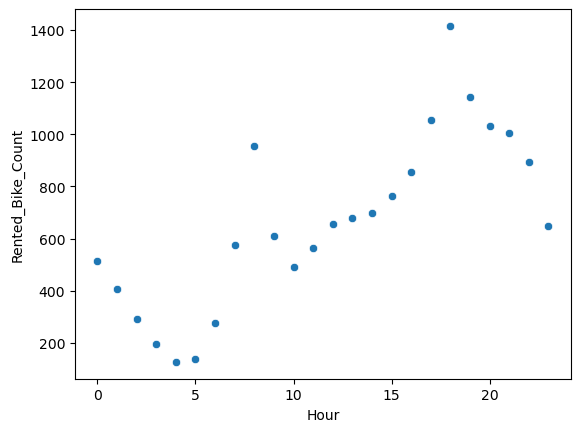

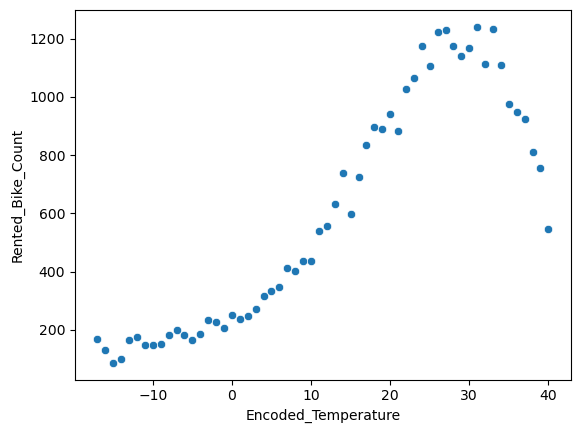

,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Demand,Encoded_Hour,Encoded_Temperature
0,0,01/12/2017,254.0,0,-5.2,37,2.2,4,-17.6,0.00,0.0,0.0,No Holiday,Yes,0,514.153285,165.202899
1,1,01/12/2017,204.0,1,-5.5,38,0.8,4,-17.6,0.00,0.0,0.0,No Holiday,Yes,0,406.412409,165.202899
2,2,01/12/2017,173.0,2,-6.0,39,1.0,4,-17.7,0.00,0.0,0.0,No Holiday,Yes,0,291.594891,182.725000
3,3,01/12/2017,107.0,3,-6.2,40,0.9,4,-17.6,0.00,0.0,0.0,No Holiday,Yes,0,195.956204,182.725000
4,4,01/12/2017,78.0,4,-6.0,36,2.3,4,-18.6,0.00,0.0,0.0,No Holiday,Yes,0,127.277372,182.725000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,26.5,69,2.3,4,20.3,0.18,0.0,0.0,No Holiday,Yes,1,1144.043796,1228.646707
6572,6572,31/08/2018,1995.0,20,25.4,74,1.6,4,20.4,0.00,0.0,0.0,No Holiday,Yes,1,1033.262774,1223.677632
6573,6573,31/08/2018,1931.0,21,24.5,78,1.2,4,20.4,0.00,0.0,0.0,No Holiday,Yes,1,1003.357664,1107.287037
6574,6574,31/08/2018,1789.0,22,24.1,80,0.9,4,20.4,0.00,0.0,0.0,No Holiday,Yes,1,895.160584,1107.287037


In [90]:
df
mean = df.groupby('Hour')['Rented_Bike_Count'].mean()
#count = df.groupby('Hour')['Rented_Bike_Count'].count()
a0 = df.groupby('Hour')['Rented_Bike_Count'].mean()
df['Encoded_Hour'] = df['Hour'].map(mean)
#df['Hour'].unique()
sns.scatterplot(data = mean)
plt.show()
plt.close()
def ceil(a):
    if(a > (a//1)):
        return (a//1) + 1
    else:
        return (a)

df['Temperature(°C)'].describe()
df['Encoded_Temperature'] = df['Temperature(°C)'].apply(ceil)

mean = df.groupby('Encoded_Temperature')['Rented_Bike_Count'].mean()
a1 = mean
df['Encoded_Temperature'] = df['Encoded_Temperature'].map(mean)
#count = df.groupby('Encoded_Temperature')['Rented_Bike_Count'].count() < 50
#count.value_counts()
def vis(a):
    if(a > 1500):
        return 4
    elif(a > 1000):
        return 3
    elif(a > 500):
        return 2
    else:
        return 1


df['Visibility (10m)'] = df['Visibility (10m)'].apply(vis)
a2 = df['Visibility (10m)']

sns.scatterplot(data = mean)

plt.show()
plt.close()# df['Humidity(%)'] = (df['Humidity(%)']) / 100    ####CHECK THIS OUT
# df['Humidity(%)']

df.describe()
df


In [91]:
df.dtypes

Id                             int64
Date                          object
Rented_Bike_Count            float64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Holiday                       object
Functioning Day               object
Demand                         int64
Encoded_Hour                 float64
Encoded_Temperature          float64
dtype: object

<Axes: xlabel='Dew_Temperature_Encoded', ylabel='Rented_Bike_Count'>

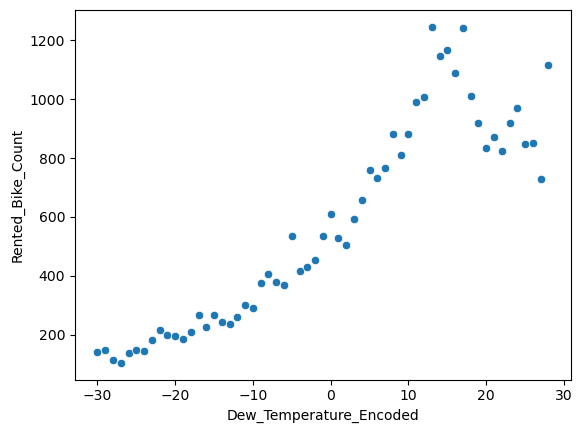

In [92]:
df['Dew_Temperature_Encoded'] = df['Dew point temperature(°C)'].apply(ceil)

mean = df.groupby('Dew_Temperature_Encoded')['Rented_Bike_Count'].mean()
a3 = mean
df['Dew_Temperature_Encoded'] = df['Dew_Temperature_Encoded'].map(mean)
mean
sns.scatterplot(data = mean)

In [93]:
# d = {
#     'Summer' : 3,
#     'Winter' : 1,
#     'Spring' : 2
# }
# df['Seasons'] = df['Seasons'].map(d)
# mean = df.groupby('Seasons')['Rented_Bike_Count'].mean()
# a4 = mean
# df['Seasons'] = df['Seasons'].map(mean)
# mean
# df
# sns.scatterplot(data = mean,linestyle = '-', markers='o')
# plt.tight_layout()
# plt.show()
# plt.close()


In [94]:
d = {
    'No Holiday' : 0,
    'Yes' : 1,
    'No' : 0,
    'Holiday':1   
}

df['Holiday'] = df['Holiday'].map(d)
df['Functioning Day'] = df['Functioning Day'].map(d)
df = df.drop(columns=['Demand'])
df

,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Encoded_Hour,Encoded_Temperature,Dew_Temperature_Encoded
0,0,01/12/2017,254.0,0,-5.2,37,2.2,4,-17.6,0.00,0.0,0.0,0,1,514.153285,165.202899,266.577320
1,1,01/12/2017,204.0,1,-5.5,38,0.8,4,-17.6,0.00,0.0,0.0,0,1,406.412409,165.202899,266.577320
2,2,01/12/2017,173.0,2,-6.0,39,1.0,4,-17.7,0.00,0.0,0.0,0,1,291.594891,182.725000,266.577320
3,3,01/12/2017,107.0,3,-6.2,40,0.9,4,-17.6,0.00,0.0,0.0,0,1,195.956204,182.725000,266.577320
4,4,01/12/2017,78.0,4,-6.0,36,2.3,4,-18.6,0.00,0.0,0.0,0,1,127.277372,182.725000,210.203704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,26.5,69,2.3,4,20.3,0.18,0.0,0.0,0,1,1144.043796,1228.646707,870.811321
6572,6572,31/08/2018,1995.0,20,25.4,74,1.6,4,20.4,0.00,0.0,0.0,0,1,1033.262774,1223.677632,870.811321
6573,6573,31/08/2018,1931.0,21,24.5,78,1.2,4,20.4,0.00,0.0,0.0,0,1,1003.357664,1107.287037,870.811321
6574,6574,31/08/2018,1789.0,22,24.1,80,0.9,4,20.4,0.00,0.0,0.0,0,1,895.160584,1107.287037,870.811321


In [95]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer

X_train = df
# scaler = PowerTransformer(method='yeo-johnson')
# X_train['Humidity(%)'] = scaler.fit_transform(X_train[['Humidity(%)']])
# scaler2 = MinMaxScaler(feature_range=(0,1))
# scaler3 = RobustScaler()
# scaler4 = PowerTransformer(method='yeo-johnson')
# scaler5 = PowerTransformer(method='yeo-johnson')
# scaler6 = PowerTransformer(method='yeo-johnson')
# scaler9 = PowerTransformer(method='yeo-johnson')
# scaler10 = PowerTransformer(method='yeo-johnson')
# scaler7 = MinMaxScaler(feature_range=(0,1))
# scaler8 = MinMaxScaler(feature_range=(0,1))
# X_train['Encoded_Temperature'] = scaler4.fit_transform(X_train[['Encoded_Temperature']])
# X_train['Dew_Temperature_Encoded'] = scaler5.fit_transform(X_train[['Dew_Temperature_Encoded']])
# X_train['Encoded_Hour'] = scaler6.fit_transform(X_train[['Encoded_Hour']])
# #X_train['Seasons'] = scaler2.fit_transform(X_train[['Seasons']])
# X_train['Visibility (10m)'] = scaler7.fit_transform(X_train[['Visibility (10m)']])
# X_train['Wind speed (m/s)'] = scaler9.fit_transform(X_train[['Wind speed (m/s)']])
# X_train['Solar Radiation (MJ/m2)'] = scaler10.fit_transform(X_train[['Solar Radiation (MJ/m2)']])

scaler100 = MinMaxScaler(feature_range=(0,1))




df['Temperature(°C)'] = df['Temperature(°C)'].apply(ceil)
df['Dew point temperature(°C)'] = df['Dew point temperature(°C)'].apply(ceil)
# sns.scatterplot(data = X_train, x='Temperature(°C)', y= 'Encoded_Temperature')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, x='Dew point temperature(°C)', y= 'Dew_Temperature_Encoded')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, y='Encoded_Hour', x= 'Hour')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.kdeplot(data=X_train, x = 'Humidity(%)')




In [96]:
#sns.kdeplot(data=X_train, x = 'Dew_Temperature_Encoded')

df

,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Encoded_Hour,Encoded_Temperature,Dew_Temperature_Encoded
0,0,01/12/2017,254.0,0,-5.0,37,2.2,4,-17.0,0.00,0.0,0.0,0,1,514.153285,165.202899,266.577320
1,1,01/12/2017,204.0,1,-5.0,38,0.8,4,-17.0,0.00,0.0,0.0,0,1,406.412409,165.202899,266.577320
2,2,01/12/2017,173.0,2,-6.0,39,1.0,4,-17.0,0.00,0.0,0.0,0,1,291.594891,182.725000,266.577320
3,3,01/12/2017,107.0,3,-6.0,40,0.9,4,-17.0,0.00,0.0,0.0,0,1,195.956204,182.725000,266.577320
4,4,01/12/2017,78.0,4,-6.0,36,2.3,4,-18.0,0.00,0.0,0.0,0,1,127.277372,182.725000,210.203704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,27.0,69,2.3,4,21.0,0.18,0.0,0.0,0,1,1144.043796,1228.646707,870.811321
6572,6572,31/08/2018,1995.0,20,26.0,74,1.6,4,21.0,0.00,0.0,0.0,0,1,1033.262774,1223.677632,870.811321
6573,6573,31/08/2018,1931.0,21,25.0,78,1.2,4,21.0,0.00,0.0,0.0,0,1,1003.357664,1107.287037,870.811321
6574,6574,31/08/2018,1789.0,22,25.0,80,0.9,4,21.0,0.00,0.0,0.0,0,1,895.160584,1107.287037,870.811321


In [97]:
X_train.drop(columns=['Temperature(°C)', 'Dew point temperature(°C)'], inplace= True)
X_train

,Id,Date,Rented_Bike_Count,Hour,Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Encoded_Hour,Encoded_Temperature,Dew_Temperature_Encoded
0,0,01/12/2017,254.0,0,37,2.2,4,0.00,0.0,0.0,0,1,514.153285,165.202899,266.577320
1,1,01/12/2017,204.0,1,38,0.8,4,0.00,0.0,0.0,0,1,406.412409,165.202899,266.577320
2,2,01/12/2017,173.0,2,39,1.0,4,0.00,0.0,0.0,0,1,291.594891,182.725000,266.577320
3,3,01/12/2017,107.0,3,40,0.9,4,0.00,0.0,0.0,0,1,195.956204,182.725000,266.577320
4,4,01/12/2017,78.0,4,36,2.3,4,0.00,0.0,0.0,0,1,127.277372,182.725000,210.203704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,69,2.3,4,0.18,0.0,0.0,0,1,1144.043796,1228.646707,870.811321
6572,6572,31/08/2018,1995.0,20,74,1.6,4,0.00,0.0,0.0,0,1,1033.262774,1223.677632,870.811321
6573,6573,31/08/2018,1931.0,21,78,1.2,4,0.00,0.0,0.0,0,1,1003.357664,1107.287037,870.811321
6574,6574,31/08/2018,1789.0,22,80,0.9,4,0.00,0.0,0.0,0,1,895.160584,1107.287037,870.811321


In [98]:
X_train['Date'] = pd.to_datetime(X_train['Date'], format="%d/%m/%Y")

# X_train['Day'] = X_train['Date'].dt.day
# X_train['Month'] = X_train['Date'].dt.month
# X_train['Year'] = X_train['Date'].dt.year
X_train['DOW'] = X_train['Date'].dt.day_of_week

# mean1 = df.groupby('Day')['Rented_Bike_Count'].mean()
# mean2 = df.groupby('Month')['Rented_Bike_Count'].mean()
# mean3 = df.groupby('Year')['Rented_Bike_Count'].mean()
mean4 = df.groupby('DOW')['Rented_Bike_Count'].mean()

X_train['DOW'] = X_train['DOW'].map(mean4)
#X_train['DOW'] = scaler8.fit_transform(X_train[['DOW']])






# sns.scatterplot(data = X_train, y='Rented_Bike_Count', x= 'Day')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, y='Rented_Bike_Count', x= 'Month')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, y='Rented_Bike_Count', x= 'Year')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, y='Rented_Bike_Count', x= 'DOW', alpha= 0.05)
# plt.tight_layout()
# plt.show()
# plt.close()


In [99]:
X_train.drop(columns=['Date', 'Id', 'Hour', 'Rainfall(mm)', 'Snowfall (cm)',
       'Holiday', 'Functioning Day', 'Humidity(%)'], inplace= True)

In [100]:
y_train = (X_train['Rented_Bike_Count'])
X_train = X_train.drop(columns=['Rented_Bike_Count'])

In [101]:
X_train = scaler100.fit_transform(X_train)

In [102]:
#########################################################################################################

In [103]:
df2 = pd.read_csv('test.csv')





df2.drop(columns=['Seasons'], inplace = True)

mean = a0

df2['Encoded_Hour'] = df2['Hour'].map(mean)

df2['Encoded_Temperature'] = df2['Temperature(°C)'].apply(ceil)
mean = a1
df2['Encoded_Temperature'] = df2['Encoded_Temperature'].map(a1)




df2['Visibility (10m)'] = df2['Visibility (10m)'].apply(vis)





df2['Dew_Temperature_Encoded'] = df2['Dew point temperature(°C)'].apply(ceil)

mean = a3
df2['Dew_Temperature_Encoded'] = df2['Dew_Temperature_Encoded'].map(mean)







# df2['Seasons'] = df2['Seasons'].map(d)
# mean = a4
# df2['Seasons'] = df2['Seasons'].map(mean)








df2['Holiday'] = df2['Holiday'].map(d)
df2['Functioning Day'] = df2['Functioning Day'].map(d)






In [104]:
X_test = df2

#X_test['Humidity(%)'] = scaler.transform(X_test[['Humidity(%)']])

# X_test['Encoded_Temperature'] = scaler4.transform(X_test[['Encoded_Temperature']])
# X_test['Dew_Temperature_Encoded'] = scaler5.transform(X_test[['Dew_Temperature_Encoded']])
# X_test['Encoded_Hour'] = scaler6.transform(X_test[['Encoded_Hour']])
# #X_test['Seasons'] = scaler2.transform(X_test[['Seasons']])
# X_test['Visibility (10m)'] = scaler7.transform(X_test[['Visibility (10m)']])
# X_test['Wind speed (m/s)'] = scaler9.transform(X_test[['Wind speed (m/s)']])
# X_test['Solar Radiation (MJ/m2)'] = scaler10.transform(X_test[['Solar Radiation (MJ/m2)']])



X_test.drop(columns=['Temperature(°C)', 'Dew point temperature(°C)'], inplace= True)








X_test['Date'] = pd.to_datetime(X_test['Date'], format="%d/%m/%Y")

X_test['DOW'] = X_test['Date'].dt.day_of_week

X_test['DOW'] = X_test['DOW'].map(mean4)
#X_test['DOW'] = scaler8.transform(X_test[['DOW']])




test_data_id = X_test['Id']

X_test.drop(columns=['Date', 'Id', 'Hour', 'Rainfall(mm)', 'Snowfall (cm)',
       'Holiday', 'Functioning Day', 'Humidity(%)'], inplace= True)

X_test = scaler100.transform(X_test)


In [105]:
#X_test['Seasons'].isna().value_counts()
#test_data_id



In [106]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, SGDRegressor

lr = LinearRegression().fit(X_train, y_train)

print(lr.score(X_train, y_train))


from sklearn.metrics import root_mean_squared_error

val_predictions = lr.predict(X_train)

# Calculate and print the Root Mean Squared Error (RMSE)
val_rmse = root_mean_squared_error((y_train), (val_predictions))
print(f"Local Validation RMSE: {val_rmse:.4f}")

0.6217799080463813
Local Validation RMSE: 392.6121


In [107]:
display(X_train)
display(X_test)

array([[0.2972973 , 1.        , 0.        , ..., 0.06810526, 0.14172947,
        1.        ],
       [0.10810811, 1.        , 0.        , ..., 0.06810526, 0.14172947,
        1.        ],
       [0.13513514, 1.        , 0.        , ..., 0.08328973, 0.14172947,
        1.        ],
       ...,
       [0.16216216, 1.        , 0.        , ..., 0.88450541, 0.67148833,
        1.        ],
       [0.12162162, 1.        , 0.        , ..., 0.88450541, 0.67148833,
        1.        ],
       [0.08108108, 1.        , 0.        , ..., 0.94236512, 0.67148833,
        1.        ]], shape=(6576, 7))

array([[0.06756757, 1.        , 0.        , ..., 0.94236512, 0.67148833,
        0.47219296],
       [0.01351351, 1.        , 0.        , ..., 0.84661392, 0.64047159,
        0.47219296],
       [0.05405405, 1.        , 0.        , ..., 0.8154449 , 0.64047159,
        0.47219296],
       ...,
       [0.04054054, 1.        , 0.        , ..., 0.16109019, 0.23679832,
        1.        ],
       [0.13513514, 1.        , 0.        , ..., 0.16109019, 0.23679832,
        1.        ],
       [0.17567568, 1.        , 0.        , ..., 0.13999   , 0.23679832,
        1.        ]], shape=(2184, 7))

In [108]:
lasso = Lasso(alpha= 1)
lasso.fit(X_train, y_train)

print(lasso.score(X_train, y_train))



val_predictions = lasso.predict(X_train)

# Calculate and print the Root Mean Squared Error (RMSE)
val_rmse = root_mean_squared_error(y_train, val_predictions)
print(f"Local Validation RMSE: {val_rmse:.4f}")
print(lasso.coef_)
print(lasso.intercept_)


0.621574901672888
Local Validation RMSE: 392.7185
[  -0.          227.55057647   99.83079332 1121.8955383   783.05399069
  366.04371481  152.87603126]
-628.5703760400762


In [109]:
ridge = Ridge(alpha= 0.001)
ridge.fit(X_train, y_train)

print(ridge.score(X_train, y_train))



val_predictions = ridge.predict(X_train)

# Calculate and print the Root Mean Squared Error (RMSE)
val_rmse = root_mean_squared_error(y_train, val_predictions)
print(f"Local Validation RMSE: {val_rmse:.4f}")
ridge.coef_


0.6217799080448847
Local Validation RMSE: 392.6121


array([ -34.66706498,  239.18633023,  119.64222955, 1140.80401594,
        762.11253707,  397.75074368,  165.96290397])

In [ ]:
# sgd = SGDRegressor(loss = "epsilon_insensitive",penalty = 'l1', alpha = 0.0001)
# sgd.fit(X_train, y_train)

# print(sgd.score(X_train, y_train))



# val_predictions = sgd.predict(X_train)

# # Calculate and print the Root Mean Squared Error (RMSE)
# val_rmse = root_mean_squared_error(y_train, val_predictions)
# print(f"Local Validation RMSE: {val_rmse:.4f}")

0.30056326611242856
Local Validation RMSE: 533.9070


c:\Users\vamsi\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [111]:
test_predictions = ridge.predict(X_test)

# Create the submission dataframe
submission = pd.DataFrame({
    'Id': test_data_id,
    'Rented_Bike_Count': (test_predictions)
})

# Display the first few rows of the submission
display(submission.head())

# Export to CSV (without the pandas index)
submission.to_csv('submission6.csv', index=False)

,Id,Rented_Bike_Count
0,6576,991.978172
1,6577,813.149658
2,6578,686.332089
3,6579,602.123386
4,6580,458.776473


In [112]:
display(submission.describe())
(submission['Rented_Bike_Count'] >= 0).value_counts()

,Id,Rented_Bike_Count
count,2184.000000,2184.000000
mean,7667.500000,737.484589
std,630.610815,449.260118
min,6576.000000,-383.930049
25%,7121.750000,415.758994
50%,7667.500000,739.614573
75%,8213.250000,1055.470996
max,8759.000000,2043.109841


Rented_Bike_Count
True     2064
False     120
Name: count, dtype: int64

In [113]:
submission[submission['Rented_Bike_Count'] < 0].sort_values(by='Rented_Bike_Count')

,Id,Rented_Bike_Count
2044,8620,-383.930049
2045,8621,-382.093352
2068,8644,-324.472069
2043,8619,-324.059704
2069,8645,-308.096954
...,...,...
964,7540,-4.827357
1755,8331,-4.617452
2050,8626,-4.513729
1034,7610,-4.066759


In [114]:
np.log1p(submission.iloc[[411,  412,  413,  414,  435,  436,  437,  438,  509,  650, 1656], :]['Rented_Bike_Count'])

411     6.483389
412     6.386619
413     6.394109
414     6.585004
435     6.500765
436     6.404970
437     6.429913
438     6.450242
509     5.800773
650     6.373584
1656    6.442208
Name: Rented_Bike_Count, dtype: float64